In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mint.utils import get_file_list
import numpy as np
from trackpy import filter_stubs

%matplotlib widget

In [9]:
input_path = r'/media/lumin/DATA/TIRF/RVG29C Results - 20251105_113343 reprocess MSD Results - 20251118_022606/' # Path to folder
paths, names = get_file_list(input_path, 'csv')

In [3]:
paths = [p for p in paths if p.endswith('nd2.csv')]
names = [n for n in names if n.endswith('nd2.csv')]

In [10]:
paths = [p for p in paths if p.endswith('rejoined.csv')]
names = [n for n in names if n.endswith('rejoined.csv')]

In [11]:
paths

['/media/lumin/DATA/TIRF/RVG29C Results - 20251105_113343 reprocess MSD Results - 20251118_022606/RVG29C Results - 20251105_113343 reprocess MSD/RVG29C/FND-COOH/20241202/20241202_SM3L1_DIV17_Lamelle_2/20241202_SM3L1_DIV17_Lamelle_2_.nd2/20241202_SM3L1_DIV17_Lamelle_2_.nd2.csv/20250924_SM9L2_DIV16_CS3_RVG29C_MLA_29.nd2_rejoined.csv_rejoined.csv',
 '/media/lumin/DATA/TIRF/RVG29C Results - 20251105_113343 reprocess MSD Results - 20251118_022606/RVG29C Results - 20251105_113343 reprocess MSD/RVG29C/FND-COOH/20241202/20241202_SM3L1_DIV17_Lamelle_2/20241202_SM3L1_DIV17_Lamelle_2_001.nd2/20241202_SM3L1_DIV17_Lamelle_2_001.nd2.csv/20250924_SM9L2_DIV16_CS3_RVG29C_MLA_29.nd2_rejoined.csv_rejoined.csv',
 '/media/lumin/DATA/TIRF/RVG29C Results - 20251105_113343 reprocess MSD Results - 20251118_022606/RVG29C Results - 20251105_113343 reprocess MSD/RVG29C/FND-COOH/20241202/20241202_SM3L1_DIV17_Lamelle_2/20241202_SM3L1_DIV17_Lamelle_2_002.nd2/20241202_SM3L1_DIV17_Lamelle_2_002.nd2.csv/20250924_SM9L2_

In [7]:
names = [name.rstrip('_rejoined.csv') for name in names]

In [8]:
import yaml
with open(r'/media/lumin/DATA/TIRF/RVG29C/already_reprocessed.yml', 'w') as f: # Otherwise create the file
            yaml.dump(names, f)

In [29]:
random_file = pd.read_csv(paths[int(np.random.rand()*len(paths))], sep='\t')
# random_id = random_file.particle.unique()[int(np.random.rand()*random_file.particle.nunique())]
# traj = random_file.loc[random_file.particle==random_id]
# traj.reset_index(inplace=True)

In [15]:
random_file.max_msd.unique()

array([7.31962515e-02, 6.87622536e-04, 3.06090823e+00, ...,
       4.15975753e-03, 3.75251360e-03, 6.73306806e-03])

In [31]:
random_file = filter_stubs(random_file, 10)

In [32]:
msd_sorted = random_file.drop_duplicates('particle')

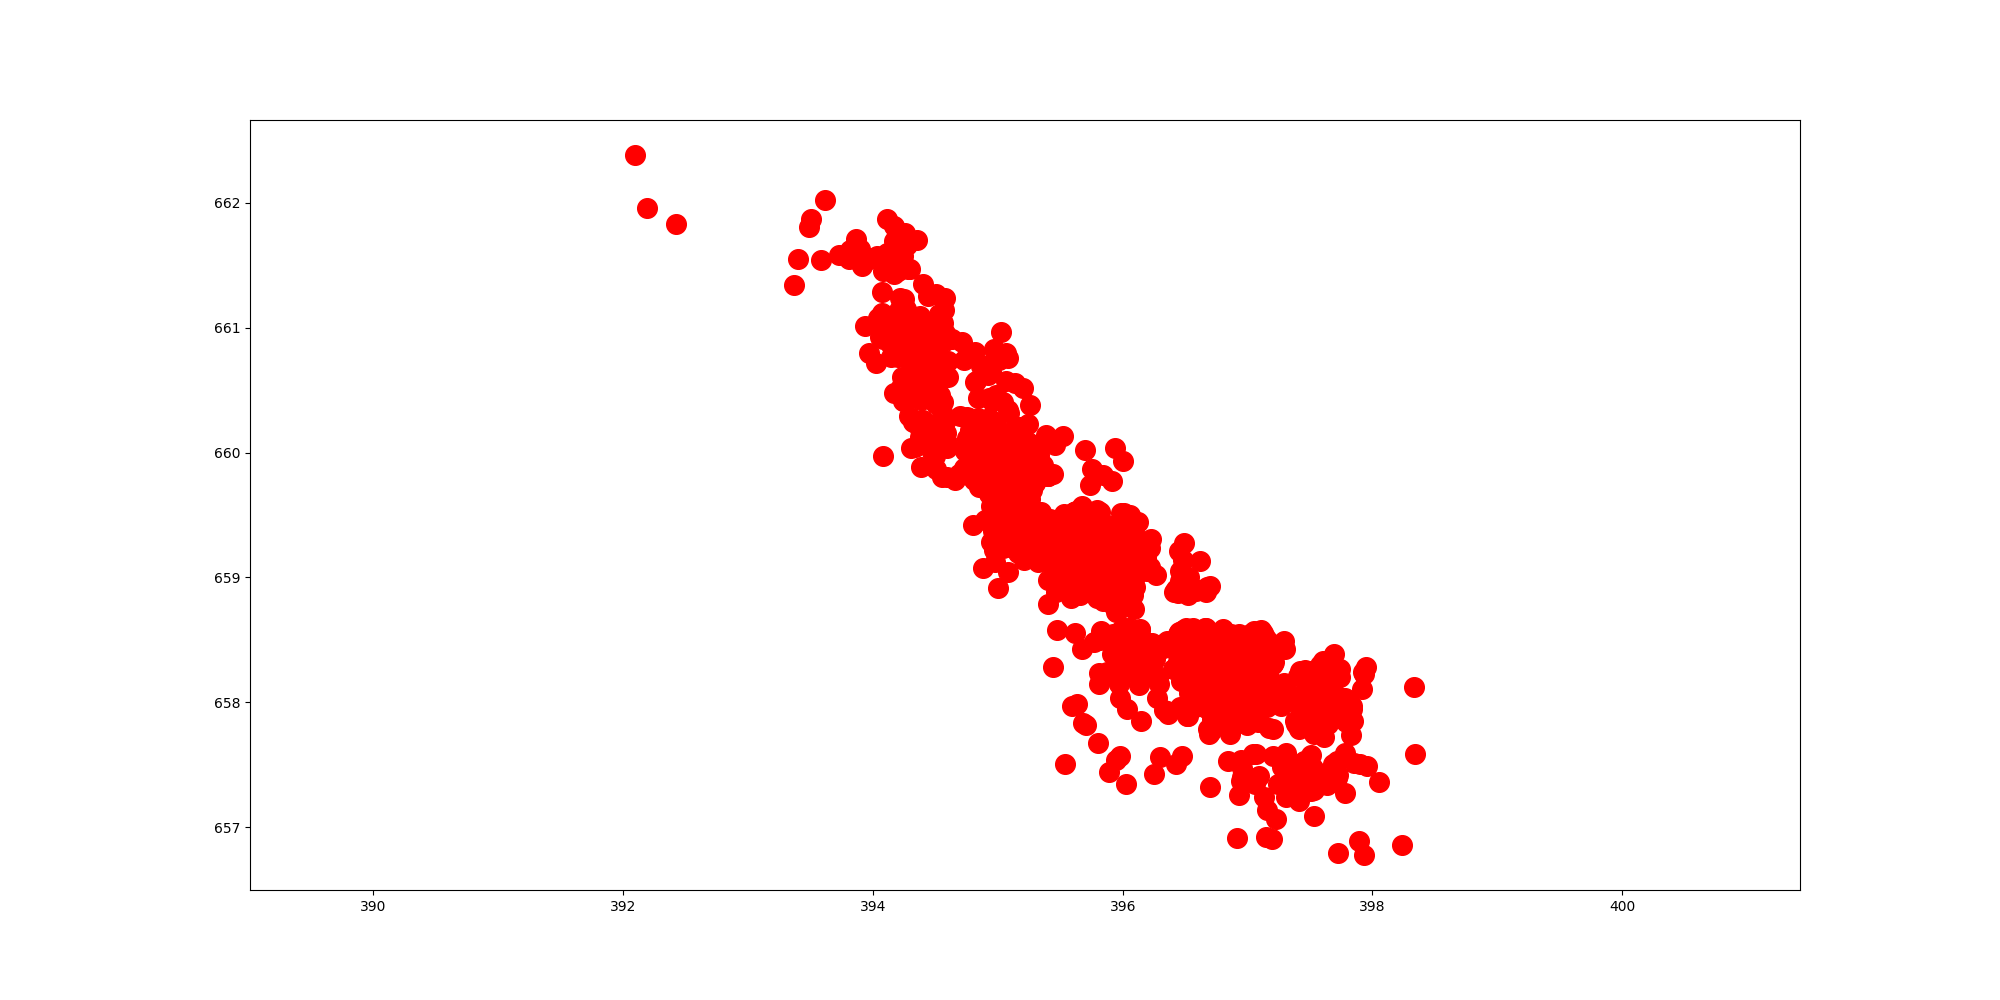

In [33]:
fig, ax1 = plt.subplots()
fig.set_size_inches(20, 10)
traj = random_file.loc[random_file.particle==2]
pl = ax1.scatter(traj.x, traj.y,c='red',s=200)
plt.axis('equal')
plt.show()

In [34]:
MSD = 3
msd_sorted = msd_sorted.sort_values('max_msd')

In [35]:
above = msd_sorted.loc[msd_sorted.max_msd > MSD]
below = msd_sorted.loc[msd_sorted.max_msd <= MSD]

In [46]:
below.loc[below.max_msd<1]

,Unnamed: 0,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle,max_msd
frame,,,,,,,,,,,,
1877,113721,293.056579,410.247368,4346.909919,1.893549,0.231696,314.579007,3672.635803,0.086494,1877,3912,0.003307
2076,126690,293.296601,409.679712,5687.123773,1.902624,0.103168,445.130182,4971.849869,0.052708,2076,4323,0.003356
2209,135402,287.509926,406.934243,5315.208971,1.896189,0.045314,402.267676,4477.387589,0.065218,2209,4574,0.003484
1328,78828,61.342602,570.418073,5407.554593,1.758509,0.168635,467.186941,4731.377136,0.041737,1328,2838,0.003559
1724,103910,249.916045,281.914179,3583.770651,1.900020,0.163998,280.817850,3334.704590,0.043019,1724,3598,0.003610
...,...,...,...,...,...,...,...,...,...,...,...,...
2066,126061,135.364477,329.043478,7672.310447,1.927214,0.166022,539.403880,7228.978134,0.046971,2066,4303,0.929531
1623,97538,418.897368,455.028947,4196.516719,2.133073,0.095135,248.477964,3975.827271,0.068518,1623,3400,0.942103
0,16,229.723972,231.342766,10885.984585,2.077130,0.195562,662.574609,10487.831497,0.033105,0,44,0.990146


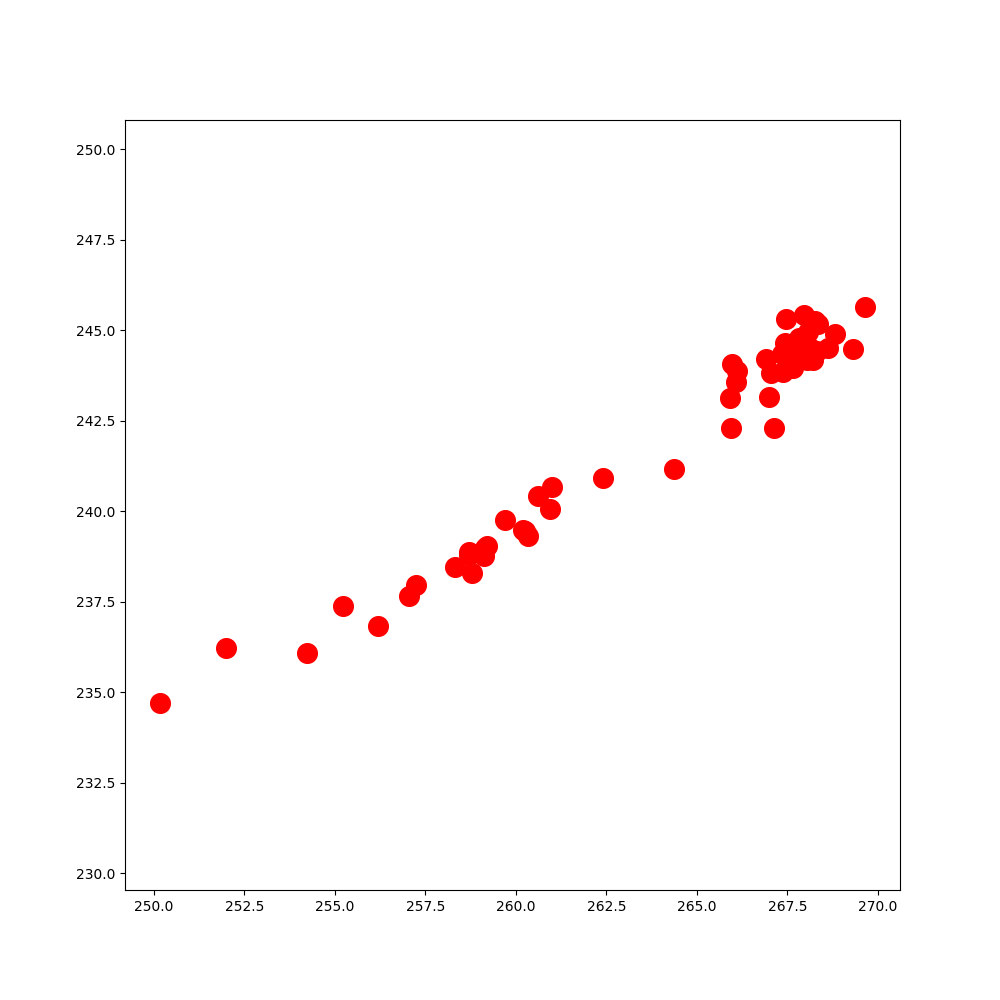

In [49]:
plt.close()
fig, ax1 = plt.subplots()
fig.set_size_inches(10, 10)
traj = random_file.loc[random_file.particle==521]
pl = ax1.scatter(traj.x, traj.y,c='red',s=200)
plt.axis('equal')
plt.show()

In [51]:
pd.DataFrame.from_dict(
                {
                    'n_particles': [0],
                    'n_static': [0],
                }
            ).to_csv(r'/home/lumin/Documents/test.csv')

In [2]:
data = pd.read_csv(r'/media/lumin/DATA/TIRF/RVG29C Results - 20251105_113343 complete Results - 20251114_143454/20251114_143454_trajectory_parameters.csv', sep='\t')

In [3]:
data.condition.unique()

array(['FND-COOH', 'FND-PEG4-RVG29C', 'FND-PEG4-RVG29C-aBTX',
       'FND-PEG4-MAL', 'FND-PEG4-RVG29', 'FND-PEG4-RVG29-BSA',
       'FND-PEG4-RVG29-BSA-MLA', 'FND-PEG12-RVG29-BSA',
       'FND-PEG4-MAL-BSA', 'FND-PEG4-RVG29C-BSA', 'FND-PEG4-RVG29C-MLA',
       'FND-COOH-35nm'], dtype=object)

In [10]:
len(['FND-COOH','FND-COOH-35nm','FND-PEG4-RVG29-BSA','FND-PEG4-RVG29-BSA-MLA','FND-PEG4-MAL','FND-PEG4-RVG29','FND-PEG4-RVG29C','FND-PEG4-RVG29C-MLA'])

8